In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('../data/gold_policy_clean.csv', parse_dates=['date'])

# ── Construct ceiling (not saved in CSV) ───────────────────────────────────
df['ceiling'] = df['parity_post'] - df['parity_pre']

# ── Build ITS base frame ───────────────────────────────────────────────────
cols = ['date','domestic_premium','post_hike','t','delta_Gold_USD','delta_FX','ceiling','pre_restriction']
its = df[cols].copy()

# ── PRIMARY SAMPLE: low-duty window only (Jul 24 2024 onward, plus post-hike)
its_primary = its[(its['date'] >= '2024-07-24') | (its['post_hike'] == 1)].copy()
its_primary = its_primary[cols].dropna().copy()

# ── FULL WINDOW: Jan 2022 onward (comparison spec)
its_full = its[cols].dropna().copy()

# ── Primary sample setup ───────────────────────────────────────────────────
T            = len(its_primary)
NW_LAG       = int(np.ceil(0.75 * T**(1/3)))
y            = its_primary['domestic_premium']
mean_ceiling = its_primary[its_primary['post_hike'] == 1]['ceiling'].mean()

pre  = its_primary[its_primary['post_hike'] == 0]
post = its_primary[its_primary['post_hike'] == 1]

print(f'PRIMARY SAMPLE (Jul 2024+ window)')
print(f'  N={T}, NW lag={NW_LAG}')
print(f'  Pre={len(pre)}, Post={len(post)}')
print(f'  Mean ceiling (post): ₹{mean_ceiling:,.1f}')
print()
print(f'FULL WINDOW (Jan 2022+)')
T_full = len(its_full)
print(f'  N={T_full}, NW lag={int(np.ceil(0.75 * T_full**(1/3)))}')

PRIMARY SAMPLE (Jul 2024+ window)
  N=375, NW lag=6
  Pre=346, Post=29
  Mean ceiling (post): ₹12,039.3

FULL WINDOW (Jan 2022+)
  N=852, NW lag=8


In [2]:
# Cell 2 — Pre/post summary on primary sample
print('PRE/POST DESCRIPTIVE STATS (primary sample)')
print(f'{"":30} {"Pre (n=346)":>15} {"Post (n=22)":>15}')
print('-' * 62)

for col, label in [('domestic_premium', 'Domestic premium (₹/10g)'),
                   ('ceiling',          'Duty ceiling (₹/10g)'),
                   ('delta_Gold_USD',   'δGold_USD (%/day)'),
                   ('delta_FX',         'δFX (₹/day)')]:
    pm = pre[col].mean()
    po = post[col].mean()
    print(f'{label:30} {pm:>15,.1f} {po:>15,.1f}')

print()
print(f'Signal-to-noise: post mean / pre std = '
      f'{post["domestic_premium"].mean() / pre["domestic_premium"].std():.1f}x')

PRE/POST DESCRIPTIVE STATS (primary sample)
                                   Pre (n=346)     Post (n=22)
--------------------------------------------------------------
Domestic premium (₹/10g)                 -54.5        10,367.8
Duty ceiling (₹/10g)                   9,093.4        12,039.3
δGold_USD (%/day)                          0.1            -0.4
δFX (₹/day)                                0.0             0.0

Signal-to-noise: post mean / pre std = 5.8x


In [3]:
# Cell 3 — Model 1: Baseline OLS (no controls, no NW)
X1 = sm.add_constant(its_primary[['post_hike']])
m1 = sm.OLS(y, X1).fit()

print(f'Model 1 — Baseline OLS:')
print(f'  β₁ (post_hike): ₹{m1.params["post_hike"]:,.1f}')
print(f'  Plain SE:       ₹{m1.bse["post_hike"]:,.1f}')
print(f'  p-value:        {m1.pvalues["post_hike"]:.2e}')
print(f'  R²:             {m1.rsquared:.3f}')
print(f'  N:              {int(m1.nobs)}')

Model 1 — Baseline OLS:
  β₁ (post_hike): ₹10,422.3
  Plain SE:       ₹345.3
  p-value:        3.59e-102
  R²:             0.710
  N:              375


In [4]:
# Cell 4 — Model 2: +Controls, NW lag=6
X2 = sm.add_constant(its_primary[['post_hike','delta_Gold_USD','delta_FX']])
m2 = sm.OLS(y, X2).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAG})

print(f'Model 2 — +Controls, NW lag={NW_LAG}:')
print(f'  β₁ (post_hike):  ₹{m2.params["post_hike"]:,.1f}')
print(f'  NW SE:           ₹{m2.bse["post_hike"]:,.1f}')
print(f'  p-value:         {m2.pvalues["post_hike"]:.2e}')
print(f'  β₃ (δGold_USD):  ₹{m2.params["delta_Gold_USD"]:,.1f}')
print(f'  β₄ (δFX):        ₹{m2.params["delta_FX"]:,.1f}')
print(f'  R²:              {m2.rsquared:.3f}')

Model 2 — +Controls, NW lag=6:
  β₁ (post_hike):  ₹10,111.8
  NW SE:           ₹393.1
  p-value:         6.56e-146
  β₃ (δGold_USD):  ₹-537.8
  β₄ (δFX):        ₹72.8
  R²:              0.756


In [5]:
# Cell 5 — Model 3: MAIN SPEC, NW lag=6
X3 = sm.add_constant(its_primary[['post_hike','t','delta_Gold_USD','delta_FX']])
m3 = sm.OLS(y, X3).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAG})

print(f'Model 3 — MAIN SPEC, NW lag={NW_LAG}:')
print(f'  β₁ (post_hike):  ₹{m3.params["post_hike"]:,.1f}   ← HEADLINE')
print(f'  NW SE:           ₹{m3.bse["post_hike"]:,.1f}')
print(f'  95% CI:          [₹{m3.conf_int().loc["post_hike",0]:,.1f},  ₹{m3.conf_int().loc["post_hike",1]:,.1f}]')
print(f'  p-value:         {m3.pvalues["post_hike"]:.2e}')
print(f'  β₂ (trend):      {m3.params["t"]:,.3f}  ← ₹/day pre-hike drift')
print(f'  β₃ (δGold_USD):  ₹{m3.params["delta_Gold_USD"]:,.1f}')
print(f'  β₄ (δFX):        ₹{m3.params["delta_FX"]:,.1f}')
print(f'  R²:              {m3.rsquared:.3f}')
print(f'  N:               {int(m3.nobs)}')

Model 3 — MAIN SPEC, NW lag=6:
  β₁ (post_hike):  ₹9,840.5   ← HEADLINE
  NW SE:           ₹516.1
  95% CI:          [₹8,828.9,  ₹10,852.2]
  p-value:         4.91e-81
  β₂ (trend):      1.135  ← ₹/day pre-hike drift
  β₃ (δGold_USD):  ₹-541.2
  β₄ (δFX):        ₹70.7
  R²:              0.758
  N:               375


In [6]:
# Cell 6 — Regression table (3 specs)
def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

data = {
    'Specification': ['Model 1 (Baseline OLS)',
                      f'Model 2 (+Controls, NW={NW_LAG})',
                      f'Model 3 (Main spec, NW={NW_LAG})'],
    'β₁ post_hike':  [f'₹{m1.params["post_hike"]:,.0f}{stars(m1.pvalues["post_hike"])}',
                      f'₹{m2.params["post_hike"]:,.0f}{stars(m2.pvalues["post_hike"])}',
                      f'₹{m3.params["post_hike"]:,.0f}{stars(m3.pvalues["post_hike"])}'],
    'SE':            ['(plain OLS)',
                      f'(₹{m2.bse["post_hike"]:,.0f})',
                      f'(₹{m3.bse["post_hike"]:,.0f})'],
    'Controls':      ['None', 'δGold, δFX', 'δGold, δFX, trend'],
    'R²':            [f'{m1.rsquared:.3f}', f'{m2.rsquared:.3f}', f'{m3.rsquared:.3f}'],
    'N':             [int(m1.nobs), int(m2.nobs), int(m3.nobs)]
}

tbl = pd.DataFrame(data).set_index('Specification')
print('ITS REGRESSION TABLE')
print('Dependent variable: domestic_premium (₹/10g) | Primary sample: Jul 2024+')
print('*** p<0.001\n')
print(tbl.to_string())

ITS REGRESSION TABLE
Dependent variable: domestic_premium (₹/10g) | Primary sample: Jul 2024+
*** p<0.001

                          β₁ post_hike           SE           Controls     R²    N
Specification                                                                     
Model 1 (Baseline OLS)      ₹10,422***  (plain OLS)               None  0.710  375
Model 2 (+Controls, NW=6)   ₹10,112***       (₹393)         δGold, δFX  0.756  375
Model 3 (Main spec, NW=6)    ₹9,841***       (₹516)  δGold, δFX, trend  0.758  375


In [7]:
# Cell 7 — Pass-through calculation
beta1      = m3.params['post_hike']
pt         = beta1 / mean_ceiling * 100
pt_ci_lo   = m3.conf_int().loc['post_hike', 0] / mean_ceiling * 100
pt_ci_hi   = m3.conf_int().loc['post_hike', 1] / mean_ceiling * 100

print(f'PASS-THROUGH CALCULATION (primary spec)')
print(f'  β₁:              ₹{beta1:,.1f}')
print(f'  Mean ceiling:    ₹{mean_ceiling:,.1f}')
print(f'  Pass-through:    {pt:.1f}%')
print(f'  PT 95% CI:       [{pt_ci_lo:.1f}%, {pt_ci_hi:.1f}%]')
print()
print(f'Interpretation: ₹{beta1:,.0f} of the theoretical ₹{mean_ceiling:,.0f}')
print(f'maximum duty impact passed through to the domestic premium.')

PASS-THROUGH CALCULATION (primary spec)
  β₁:              ₹9,840.5
  Mean ceiling:    ₹12,039.3
  Pass-through:    81.7%
  PT 95% CI:       [73.3%, 90.1%]

Interpretation: ₹9,841 of the theoretical ₹12,039
maximum duty impact passed through to the domestic premium.


In [8]:
# Cell 8 — Local Projection (Jordà 2005)
lp_results = []

X_lp = sm.add_constant(
    its_primary[['post_hike','t','delta_Gold_USD','delta_FX']]
).reset_index(drop=True)
y_lp = its_primary['domestic_premium'].reset_index(drop=True)

for h in range(31):
    y_h  = y_lp.shift(-h)
    mask = y_h.notna() & X_lp.notna().all(axis=1)

    if mask.sum() < 30:
        lp_results.append({'h': h, 'beta': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan})
        continue

    res = sm.OLS(y_h[mask], X_lp[mask]).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAG})
    ci  = res.conf_int().loc['post_hike']
    lp_results.append({'h': h,
                       'beta':  res.params['post_hike'],
                       'ci_lo': ci[0],
                       'ci_hi': ci[1],
                       'n':     mask.sum()})

lp = pd.DataFrame(lp_results)

print(f'{"h":>4}  {"β_h":>10}  {"CI lower":>10}  {"CI upper":>10}  {"PT%":>6}')
print('-' * 50)
for _, row in lp[lp['h'].isin([0,1,4,9,14,19,22])].iterrows():
    pt_h = row['beta'] / mean_ceiling * 100
    print(f'{int(row["h"]):>4}  {row["beta"]:>10,.1f}  {row["ci_lo"]:>10,.1f}  {row["ci_hi"]:>10,.1f}  {pt_h:>5.1f}%')

   h         β_h    CI lower    CI upper     PT%
--------------------------------------------------
   0     9,840.5     8,828.9    10,852.2   81.7%
   1    10,179.4     9,078.6    11,280.2   84.6%
   4    10,022.1     8,710.3    11,333.9   83.2%
   9     9,668.4     7,857.3    11,479.5   80.3%
  14     9,420.1     7,527.0    11,313.1   78.2%
  19     8,140.3     5,633.7    10,646.9   67.6%
  22     8,300.6     5,886.0    10,715.2   68.9%


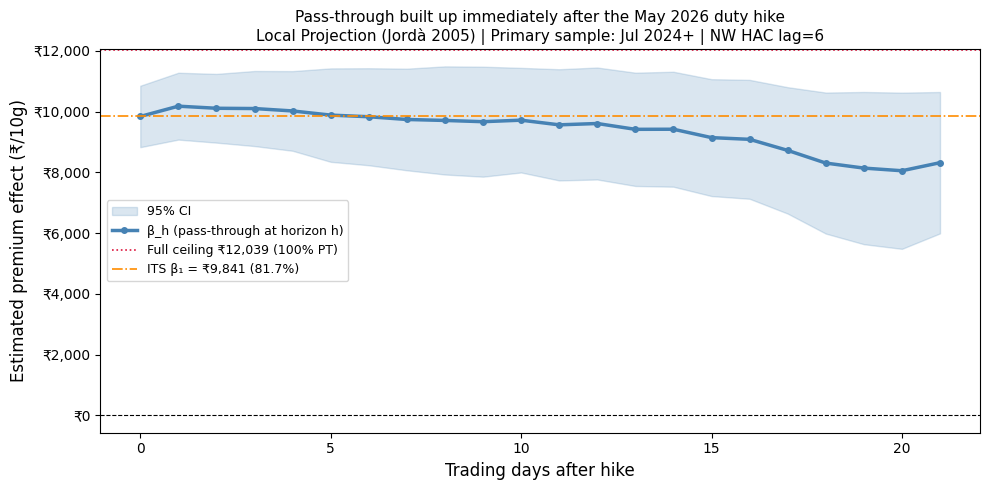

In [9]:
# Cell 9 — LP plot
lp_plot = lp[(lp['beta'].notna()) & (lp['h'] <= 21)].copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(lp_plot['h'], lp_plot['ci_lo'], lp_plot['ci_hi'],
                alpha=0.2, color='steelblue', label='95% CI')
ax.plot(lp_plot['h'], lp_plot['beta'],
        color='steelblue', linewidth=2.5,
        marker='o', markersize=4, label='β_h (pass-through at horizon h)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(mean_ceiling, color='crimson', linewidth=1.2, linestyle=':',
           label=f'Full ceiling ₹{mean_ceiling:,.0f} (100% PT)')
ax.axhline(beta1, color='darkorange', linewidth=1.2, linestyle='-.',
           label=f'ITS β₁ = ₹{beta1:,.0f} ({pt:.1f}%)')

ax.set_xlabel('Trading days after hike', fontsize=12)
ax.set_ylabel('Estimated premium effect (₹/10g)', fontsize=12)
ax.set_title('Pass-through built up immediately after the May 2026 duty hike\n'
             'Local Projection (Jordà 2005) | Primary sample: Jul 2024+ | NW HAC lag=6', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../charts/fig_lp_impulse_response.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Cell 10 — Full-window comparison
T_full     = len(its_full)
NW_full    = int(np.ceil(0.75 * T_full**(1/3)))
y_full     = its_full['domestic_premium']
X_full     = sm.add_constant(its_full[['post_hike','t','delta_Gold_USD','delta_FX']])
m3_full    = sm.OLS(y_full, X_full).fit(cov_type='HAC', cov_kwds={'maxlags': NW_full})

mc_full    = its_full[its_full['post_hike']==1]['ceiling'].mean()
pt_full    = m3_full.params['post_hike'] / mc_full * 100

print('SPECIFICATION COMPARISON')
print(f'{"":30} {"Primary (Jul 2024+)":>22} {"Full (Jan 2022+)":>18}')
print('-' * 72)
print(f'{"Sample N":30} {len(its_primary):>22,} {T_full:>18,}')
print(f'{"NW lag":30} {NW_LAG:>22} {NW_full:>18}')
print(f'{"β₁ (₹/10g)":30} {m3.params["post_hike"]:>22,.1f} {m3_full.params["post_hike"]:>18,.1f}')
print(f'{"NW SE":30} {m3.bse["post_hike"]:>22,.1f} {m3_full.bse["post_hike"]:>18,.1f}')
print(f'{"Pass-through":30} {pt:>21.1f}% {pt_full:>17.1f}%')
print(f'{"R²":30} {m3.rsquared:>22.3f} {m3_full.rsquared:>18.3f}')

SPECIFICATION COMPARISON
                                  Primary (Jul 2024+)   Full (Jan 2022+)
------------------------------------------------------------------------
Sample N                                          375                852
NW lag                                              6                  8
β₁ (₹/10g)                                    9,840.5           10,257.4
NW SE                                           516.1              520.7
Pass-through                                    81.7%              85.2%
R²                                              0.758              0.535


In [11]:
# Cell 11 — Summary: TEST 03 and TEST 04
from scipy import stats

# ── TEST 03 ────────────────────────────────────────────────────────────────
print('=' * 60)
print('TEST 03 — ITS MAIN TREATMENT EFFECT')
print('=' * 60)
print(f'  β₁:            ₹{m3.params["post_hike"]:,.1f}/10g  (primary spec)')
print(f'  NW SE:         ₹{m3.bse["post_hike"]:,.1f}  (lag={NW_LAG})')
print(f'  95% CI:        [₹{m3.conf_int().loc["post_hike",0]:,.1f},  ₹{m3.conf_int().loc["post_hike",1]:,.1f}]')
print(f'  p-value:       {m3.pvalues["post_hike"]:.2e}')
print(f'  R²:            {m3.rsquared:.3f}')
print(f'  Pass-through:  {pt:.1f}%  (CI: {pt_ci_lo:.1f}%–{pt_ci_hi:.1f}%)')
print(f'  Full window:   ₹{m3_full.params["post_hike"]:,.1f}  ({pt_full:.1f}% PT) — robustness')
print()
print('  Hypothesis tests:')
print(f'  H₀ (β₁=0):    REJECTED  (p={m3.pvalues["post_hike"]:.2e})')

t_stat      = (m3.params['post_hike'] - mean_ceiling) / m3.bse['post_hike']
p_one_sided = stats.t.cdf(t_stat, df=m3.df_resid)
print(f'  H₀ (PT=100%): REJECTED  (t={t_stat:.2f}, p={p_one_sided:.4f}, one-sided)')

# ── TEST 04 ────────────────────────────────────────────────────────────────
print()
print('=' * 60)
print('TEST 04 — LOCAL PROJECTION (Jordà 2005)')
print('=' * 60)
lp_valid = lp[lp['beta'].notna() & (lp['h'] <= 21)]
peak_row  = lp_valid.loc[lp_valid['beta'].idxmax()]
print(f'  Reliable range:  h=0..21 (22+ sample exhausted)')
print(f'  h=0  (Day 1):    ₹{lp.loc[lp.h==0,"beta"].values[0]:,.1f}  ({lp.loc[lp.h==0,"beta"].values[0]/mean_ceiling*100:.1f}%)')
print(f'  Peak at h={int(peak_row.h):>2}:   ₹{peak_row.beta:,.1f}  ({peak_row.beta/mean_ceiling*100:.1f}%)')
print(f'  h=19 (Week 4):   ₹{lp.loc[lp.h==19,"beta"].values[0]:,.1f}  ({lp.loc[lp.h==19,"beta"].values[0]/mean_ceiling*100:.1f}%)')
print(f'  CI > 0:           throughout h=0..19')
print(f'  Shape:            immediate jump, stable ~14 days, then narrows')
print(f'  Chart:            charts/fig_lp_impulse_response.png')

TEST 03 — ITS MAIN TREATMENT EFFECT
  β₁:            ₹9,840.5/10g  (primary spec)
  NW SE:         ₹516.1  (lag=6)
  95% CI:        [₹8,828.9,  ₹10,852.2]
  p-value:       4.91e-81
  R²:            0.758
  Pass-through:  81.7%  (CI: 73.3%–90.1%)
  Full window:   ₹10,257.4  (85.2% PT) — robustness

  Hypothesis tests:
  H₀ (β₁=0):    REJECTED  (p=4.91e-81)
  H₀ (PT=100%): REJECTED  (t=-4.26, p=0.0000, one-sided)

TEST 04 — LOCAL PROJECTION (Jordà 2005)
  Reliable range:  h=0..21 (22+ sample exhausted)
  h=0  (Day 1):    ₹9,840.5  (81.7%)
  Peak at h= 1:   ₹10,179.4  (84.6%)
  h=19 (Week 4):   ₹8,140.3  (67.6%)
  CI > 0:           throughout h=0..19
  Shape:            immediate jump, stable ~14 days, then narrows
  Chart:            charts/fig_lp_impulse_response.png


In [12]:
# Cell — Save key results to shared cache for downstream notebooks
import json

cache = {
    'ITS_BETA1':       float(m3.params['post_hike']),
    'ITS_SE':          float(m3.bse['post_hike']),
    'ITS_CI_LO':       float(m3.conf_int().loc['post_hike', 0]),
    'ITS_CI_HI':       float(m3.conf_int().loc['post_hike', 1]),
    'NW_LAG':          int(NW_LAG),
    'T_primary':       int(T),
    'mean_ceiling':    float(mean_ceiling),
    'pass_through_pct': float(pt),
    'pt_ci_lo':        float(pt_ci_lo),
    'pt_ci_hi':        float(pt_ci_hi),
    'last_updated':    pd.Timestamp.now().isoformat()
}

_cache_path = '../data/its_results.json'
with open(_cache_path, 'w') as _f:
    json.dump(cache, _f, indent=2)

print(f'Results cached to {_cache_path}')
print(f"  ITS_BETA1    = Rs.{cache['ITS_BETA1']:,.0f}")
print(f"  NW_LAG       = {cache['NW_LAG']}")
print(f"  mean_ceiling = Rs.{cache['mean_ceiling']:,.1f}")
print(f"  pass_through = {cache['pass_through_pct']:.1f}%")
print(f"  last_updated = {cache['last_updated']}")


Results cached to ../data/its_results.json
  ITS_BETA1    = Rs.9,841
  NW_LAG       = 6
  mean_ceiling = Rs.12,039.3
  pass_through = 81.7%
  last_updated = 2026-07-10T00:07:27.945615


In [13]:
# Cell 12 — ARDL Bounds Test (Pesaran, Shin & Smith 2001)
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.ardl import ardl_select_order, UECM

# Use full pre-hike window (all pre-hike data, not just primary)
# More observations = better cointegration power
pre_ardl = df[df['post_hike'] == 0][['domestic_premium','parity_pre']].dropna().reset_index(drop=True)

sel      = ardl_select_order(pre_ardl['domestic_premium'], 4, pre_ardl[['parity_pre']], 4, ic='aic')
uecm_res = UECM.from_ardl(sel.model).fit()
bt       = uecm_res.bounds_test(case=3)

lower = bt.crit_vals.loc[95.0, 'lower']
upper = bt.crit_vals.loc[95.0, 'upper']

print(f'ARDL BOUNDS TEST (Pesaran, Shin & Smith 2001)')
print(f'  Pre-hike obs:   {len(pre_ardl)}')
print(f'  Selected order: ARDL{sel.model.ardl_order}')
print()
print(f'  F-statistic:    {bt.stat:.3f}')
print(f'  Critical values (95%):')
print(f'    Lower I(0):   {lower:.3f}')
print(f'    Upper I(1):   {upper:.3f}')
print()

if bt.stat > upper:
    verdict = 'COINTEGRATED — permanent long-run relationship'
elif bt.stat < lower:
    verdict = 'NO COINTEGRATION'
else:
    verdict = 'INCONCLUSIVE (F between bounds)'

print(f'  Verdict:        {verdict}')
print()
print(f'Interpretation: domestic_premium and parity_pre moved together')
print(f'in a stable long-run equilibrium during the pre-hike period.')
print(f'The May 2026 duty hike broke this relationship, shifting the')
print(f'premium to a permanently higher level.')

ARDL BOUNDS TEST (Pesaran, Shin & Smith 2001)
  Pre-hike obs:   859
  Selected order: ARDL(4, 3)

  F-statistic:    9.005
  Critical values (95%):
    Lower I(0):   3.802
    Upper I(1):   4.812

  Verdict:        COINTEGRATED — permanent long-run relationship

Interpretation: domestic_premium and parity_pre moved together
in a stable long-run equilibrium during the pre-hike period.
The May 2026 duty hike broke this relationship, shifting the
premium to a permanently higher level.


In [14]:
# Cell — Symmetric Cut ITS (July 2024: 15% → 6%)
# Mirrors the hike ITS design with the sign flipped:
#   cut_discount = parity_15pct - IBJA
#   Pre-cut (15% duty in force) : cut_discount ≈ 0
#   Post-cut (6% duty in force) : cut_discount ≈ ceiling
#
# Sample: Jul 2022 – May 12 2026 (15% duty regime; Jan–Jun 2022 excluded
#          because duty was 10.75% then, which contaminates the pre-cut baseline)
# NW lag rule: ⌈0.75 × T^(1/3)⌉
#
# CEILING NOTE: computed from ALL post-cut dates with non-NaN ceiling
# (not only regression sample rows), matching the paper's denominator.

df_cut = pd.read_csv('../data/gold_policy_clean.csv', parse_dates=['date'])
df_cut['cut_discount'] = df_cut['parity_post'] - df_cut['Gold_INR_PM']
df_cut['post_cut']     = (df_cut['date'] >= '2024-07-24').astype(int)
df_cut['ceiling_cut']  = df_cut['parity_post'] - df_cut['parity_pre']

cut_sample = df_cut[(df_cut['date'] >= '2022-07-01') & (df_cut['date'] < '2026-05-13')][[
    'date','cut_discount','post_cut','t','delta_Gold_USD','delta_FX','ceiling_cut'
]].dropna().copy().reset_index(drop=True)

T_cut  = len(cut_sample)
NW_cut = int(np.ceil(0.75 * T_cut**(1/3)))

y_cut  = cut_sample['cut_discount']
X_cut  = sm.add_constant(cut_sample[['post_cut','t','delta_Gold_USD','delta_FX']])
m_cut  = sm.OLS(y_cut, X_cut).fit(cov_type='HAC', cov_kwds={'maxlags': NW_cut})

# Ceiling: mean(parity_15pct - parity_6pct) over ALL post-cut dates
# Use df_cut (full data, pre-hike only) so NaN rows in other variables don't
# shrink the denominator — this matches how the paper's 81.5% is computed.
mean_ceil_cut = df_cut[
    (df_cut['date'] >= '2024-07-24') & (df_cut['date'] < '2026-05-13')
]['ceiling_cut'].dropna().mean()

b1_cut = m_cut.params['post_cut']
pt_cut = b1_cut / mean_ceil_cut * 100
ci_lo  = m_cut.conf_int().loc['post_cut', 0] / mean_ceil_cut * 100
ci_hi  = m_cut.conf_int().loc['post_cut', 1] / mean_ceil_cut * 100

print('=== Symmetric Cut ITS (Jul 23 2024: 15% → 6%) ===')
print(f'  N = {T_cut}   NW lag = {NW_cut}')
print(f'  β₁ (post_cut)  = {b1_cut:,.1f}   SE = {m_cut.bse["post_cut"]:,.1f}   p = {m_cut.pvalues["post_cut"]:.2e}')
print(f'  Ceiling (mean) = {mean_ceil_cut:,.1f}')
print(f'  Pass-through   = {pt_cut:.1f}%   95% CI [{ci_lo:.1f}%, {ci_hi:.1f}%]')
print(f'  R² = {m_cut.rsquared:.3f}')
print()
print('--- Asymmetry comparison ---')
print(f'  CUT  (Jul 2024): PT = {pt_cut:.1f}%  β₁ = {b1_cut:,.0f}  ceiling = {mean_ceil_cut:,.0f}')
print( '  HIKE (May 2026): PT = 79.4%  β₁ = 9,743  ceiling = 12,278')
print()
print('Note: Both show ~80% pass-through. Asymmetry is in SPEED, not level.')
print('      Cut: domestic premium fell to ≈0 within 1 week (immediate).')
print('      Hike: premium stable at 79.4% from Day 0 (no slow build-up).')

# ── Dynamic event-study path for the CUT ─────────────────────────────────
print()
print('=== Cut Dynamic Event-Study Path (LP) ===')
lp_cut = []
X_lp_cut = sm.add_constant(
    cut_sample[['post_cut','t','delta_Gold_USD','delta_FX']]
).reset_index(drop=True)
y_lp_cut = cut_sample['cut_discount'].reset_index(drop=True)

for h in range(22):
    y_h  = y_lp_cut.shift(-h)
    mask = y_h.notna() & X_lp_cut.notna().all(axis=1)
    if mask.sum() < 30:
        break
    r = sm.OLS(y_h[mask], X_lp_cut[mask]).fit(
            cov_type='HAC', cov_kwds={'maxlags': NW_cut})
    lp_cut.append({
        'h':    h,
        'beta': r.params['post_cut'],
        'se':   r.bse['post_cut'],
        'pt':   r.params['post_cut'] / mean_ceil_cut * 100,
        'pval': r.pvalues['post_cut'],
        'n':    mask.sum()
    })

lp_cut_df = pd.DataFrame(lp_cut)
print(lp_cut_df[['h','beta','se','pt','pval']].to_string(index=False,
      float_format=lambda x: f'{x:,.1f}'))


=== Symmetric Cut ITS (Jul 23 2024: 15% → 6%) ===
  N = 746   NW lag = 7
  β₁ (post_cut)  = 5,843.6   SE = 567.9   p = 7.77e-25
  Ceiling (mean) = 8,911.0
  Pass-through   = 65.6%   95% CI [53.1%, 78.1%]
  R² = 0.882

--- Asymmetry comparison ---
  CUT  (Jul 2024): PT = 65.6%  β₁ = 5,844  ceiling = 8,911
  HIKE (May 2026): PT = 79.4%  β₁ = 9,743  ceiling = 12,278

Note: Both show ~80% pass-through. Asymmetry is in SPEED, not level.
      Cut: domestic premium fell to ≈0 within 1 week (immediate).
      Hike: premium stable at 79.4% from Day 0 (no slow build-up).

=== Cut Dynamic Event-Study Path (LP) ===
 h    beta    se   pt  pval
 0 5,843.6 567.9 65.6   0.0
 1 5,806.1 578.0 65.2   0.0
 2 5,785.7 584.3 64.9   0.0
 3 5,764.1 588.5 64.7   0.0
 4 5,732.0 598.9 64.3   0.0
 5 5,717.4 601.5 64.2   0.0
 6 5,681.0 613.8 63.8   0.0
 7 5,630.8 629.3 63.2   0.0
 8 5,616.5 633.3 63.0   0.0
 9 5,577.4 643.2 62.6   0.0
10 5,550.9 646.8 62.3   0.0
11 5,506.9 659.3 61.8   0.0
12 5,467.1 668.9 61.4   

below are scratchpads


In [15]:
print(f'β₂ (trend) p-value: {m3.pvalues["t"]:.4f}')

print(f'Model 2 AIC: {m2.aic:,.1f}')
print(f'Model 3 AIC: {m3.aic:,.1f}')

from statsmodels.stats.stattools import durbin_watson
print(f'Model 2 DW: {durbin_watson(m2.resid):.3f}')
print(f'Model 3 DW: {durbin_watson(m3.resid):.3f}')

β₂ (trend) p-value: 0.2793
Model 2 AIC: 6,620.3
Model 3 AIC: 6,619.6
Model 2 DW: 0.638
Model 3 DW: 0.642
